In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df_timeseries = pd.read_csv("/Users/zahrataghizadeh/Desktop/ADA/YouNiverse/df_timeseries_en.tsv.gz", compression="infer", sep="\t")
#df_metadata = pd.read_csv("/Users/zahrataghizadeh/Desktop/ADA/YouNiverse/yt_metadata_en.jsonl.gz", compression="infer", sep="\t")

In [10]:
# check the columns of the dataframe
print(df_timeseries.columns)

# check the shape of the dataframe
print(df_timeseries.shape)
#get the unique values for category column
print(df_timeseries['category'].unique())

# only get the rows where the column 'category' is Sports
df_timeseries_sports = df_timeseries[df_timeseries['category'] == 'Sports']
print('Sport channel number: ', df_timeseries_sports.shape)

Index(['channel', 'category', 'datetime', 'views', 'delta_views', 'subs',
       'delta_subs', 'videos', 'delta_videos', 'activity'],
      dtype='object')
(18872499, 10)
['Film and Animation' 'Music' 'Comedy' 'Gaming' 'Science & Technology'
 'Sports' 'Entertainment' 'Education' 'Nonprofits & Activism'
 'People & Blogs' 'Howto & Style' 'News & Politics' 'Travel & Events'
 'Autos & Vehicles' 'Pets & Animals' nan]
Sport channel number:  (762263, 10)


In [41]:
# print one row of the dataframe
# datetime is in the following format: 2020-01-01 00:00:00, YYYY/MM/DD

# Plotting the number of views for the sports category during time. have month and year on x-axis and number of views on y-axis
df_timeseries_sports['datetime'] = pd.to_datetime(df_timeseries_sports['datetime'])
#print(df_timeseries_sports)

# get the latest and the earliest date
print('Latest date: ', df_timeseries_sports['datetime'].max())
print('Earliest date: ', df_timeseries_sports['datetime'].min())


Latest date:  2019-09-30 01:00:00
Earliest date:  2015-06-01 00:00:00


/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_13083/2804355653.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeseries_sports['datetime'] = pd.to_datetime(df_timeseries_sports['datetime'])


In [40]:
# group the data by month and year
df_timeseries_sports['month'] = df_timeseries_sports['datetime'].dt.month
df_timeseries_sports['year'] = df_timeseries_sports['datetime'].dt.year
df_timeseries_sports_grouped = df_timeseries_sports.groupby(['year', 'month'])
df_timeseries_sports_grouped = df_timeseries_sports_grouped['delta_views'].sum()
df_timeseries_sports_grouped = df_timeseries_sports_grouped.reset_index()
print(df_timeseries_sports_grouped)



    year  month   delta_views
0   2015      6  8.172025e+04
1   2015      7  4.472291e+05
2   2015      8  3.696148e+06
3   2015      9  8.646343e+06
4   2015     10  1.237819e+07
5   2015     11  1.419537e+07
6   2015     12  1.361178e+06
7   2016      1  1.935895e+06
8   2016      2  2.646350e+07
9   2016      3  2.591638e+07
10  2016      4  5.329440e+07
11  2016      5  1.086108e+08
12  2016      6  1.588742e+08
13  2016      7  2.437597e+08
14  2016      8  4.640254e+08
15  2016      9  4.301398e+08
16  2016     10  2.490736e+09
17  2016     11  3.025669e+09
18  2016     12  3.052891e+09
19  2017      1  4.951677e+09
20  2017      2  3.354136e+09
21  2017      3  3.629185e+09
22  2017      4  3.958791e+09
23  2017      5  5.122546e+09
24  2017      6  4.197555e+09
25  2017      7  5.188233e+09
26  2017      8  4.172800e+09
27  2017      9  4.139471e+09
28  2017     10  5.471630e+09
29  2017     11  5.009001e+09
30  2017     12  5.914603e+09
31  2018      1  5.449403e+09
32  2018  

/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_13083/48211594.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeseries_sports['month'] = df_timeseries_sports['datetime'].dt.month
/var/folders/77/5ydnmbx94b19w3vljgff8zlm0000gn/T/ipykernel_13083/48211594.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_timeseries_sports['year'] = df_timeseries_sports['datetime'].dt.year


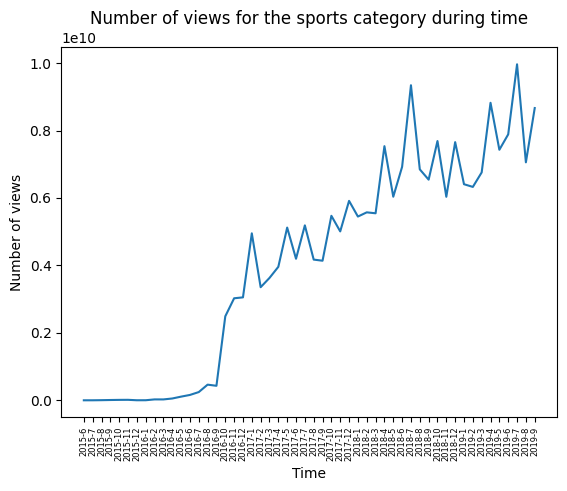

In [34]:
# plot the number of views for the sports category during time, on the x-axis have discritized time in months and on the y-axis the number of views
plt.plot(df_timeseries_sports_grouped['year'].astype(str) + '-' + df_timeseries_sports_grouped['month'].astype(str), df_timeseries_sports_grouped['delta_views'])
plt.xlabel('Time')
plt.ylabel('Number of views')   
plt.title('Number of views for the sports category during time')
# decrease the size of the x-axis labels
plt.xticks(fontsize=6)
# rotate the x-axis labels
plt.xticks(rotation=90)
plt.show()


# plot the number of views for the sports category during time, on the x-axis have discritized time in months and on the y-axis the number of views
plt.plot(df_timeseries_sports_grouped['year'].astype(str) + '-' + df_timeseries_sports_grouped['month'].astype(str), df_timeseries_sports_grouped['d_views'])
plt.xlabel('Time')
plt.ylabel('Number of views')   
plt.title('Number of views for the sports category during time')
# decrease the size of the x-axis labels
plt.xticks(fontsize=6)
# rotate the x-axis labels
plt.xticks(rotation=90)
plt.show()